# **Sampling coverage**

Author: Daning Montaño - Ocampo

Kernel: R

# **1. Packages and libraries**

In [1]:
suppressMessages({
library(dplyr)
library(ggplot2)
library(sf)
library(iNEXT)
library(tidyr)
library(vegan)
library(tibble)
library(gstat)
library(ggplot2)
})
#library(doParallel)
#

Warning messages:
1: package ‘dplyr’ was built under R version 4.3.3 
2: package ‘iNEXT’ was built under R version 4.3.3 
3: package ‘tidyr’ was built under R version 4.3.3 


# 2. Load clean data and grids

## 2.1. Ocurrences

In [2]:
bio_records = read.csv( "../../../DATOS/Datasets/Biodiversidad/biodiversidad_ocurrences_clean.csv")|>
  filter(coordinateUncertaintyInMeters <= 5000 | is.na(coordinateUncertaintyInMeters))

# Transform to sf object
bio_records_sf = st_as_sf(
  bio_records,
  coords = c("decimalLongitude", "decimalLatitude"),
  crs = 4326
) |>
  st_transform(32717)

## 2.2. Grids

In [3]:
grids_1km_buffer = st_read("../../../DATOS/SHP/Grids/grid_zamora_ch_buffer_1km.shp")


Reading layer `grid_zamora_ch_buffer_1km' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Grids\grid_zamora_ch_buffer_1km.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 15779 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 675083.7 ymin: 9444351 xmax: 794083.7 ymax: 9631351
Projected CRS: WGS 84 / UTM zone 17S


# 3. Join points to grids

By locating the points, we will extract ID information from the grid tables. This allows us to work on the analyses and simply join the results to the grid, making the process more efficient.

In [18]:
# Vector of vascular plant classes (Tracheophyta)
vascular_plants <- c(
  "Equisetopsida", 
  "Liliopsida", 
  "Magnoliopsida", 
  "Lycopodiopsida", 
  "Polypodiopsida", 
  "Pinopsida", 
  "Gnetopsida"
)

# Join and Filtering Logic
records_grid_1km_buffer <- st_join(
  bio_records_sf,
  grids_1km_buffer %>% select(id),   
  join = st_within
) %>% 
  mutate(
    Group = case_when(
      # Solo asigna "Plants" si es Plantae Y es vascular
      kingdom == "Plantae" & class %in% vascular_plants ~ "Plants",
      
      # Lógica para Animales
      kingdom == "Animalia" & class %in% c("Reptilia", "Squamata") ~ "Reptilia",
      kingdom == "Animalia" & class %in% c("Amphibia", "Aves", "Mammalia") ~ class,
      
      # Todo lo demás (incluyendo plantas no vasculares) será NA
      TRUE ~ NA_character_
    )
  ) %>% 
  # Opcional: Eliminar las filas que quedaron como NA (incluye las no vasculares)
  filter(!is.na(Group))

# 4. Records and sp per 1 km grid

All

In [19]:
total_records_species_per_grid= records_grid_1km_buffer |>
  as.data.frame() |>
  dplyr::group_by(id) |>
  dplyr::summarise(
    Total_records  = dplyr::n(),                     # número total de registros
    Total_species  = dplyr::n_distinct(scientificName) # número de especies únicas
  ) |>
  as.data.frame()


By group

In [ ]:
total_records_species_per_grid_plants = records_grid_1km_buffer |>
  as.data.frame() |>
  dplyr::filter(kingdom == "Plantae") |>
  dplyr::group_by(id) |>
  dplyr::summarise(
    Total_records  = dplyr::n(),                     # número total de registros
    Total_species  = dplyr::n_distinct(scientificName) # número de especies únicas
  ) |>
  mutate(Group = "Plants")|>
  as.data.frame()


total_records_species_per_grid_animals = records_grid_1km_buffer |>
  as.data.frame() |>
  dplyr::filter(kingdom == "Animalia") |>
  dplyr::filter(class %in% c("Amphibia","Aves","Mammalia","Reptilia","Squamata")) |>
  dplyr::mutate(
    Group = dplyr::case_when(
      class %in% c("Reptilia","Squamata") ~ "Reptilia",
      TRUE ~ class
    )
  ) |>
  dplyr::group_by(Group, id) |>
  dplyr::summarise(
    Total_records = dplyr::n(),
    Total_species = dplyr::n_distinct(scientificName)
  ) |>
  as.data.frame()

total_record_sp_by_group = rbind(total_records_species_per_grid_plants, total_records_species_per_grid_animals)
total_record_sp_by_group

`summarise()` has grouped output by 'Group'. You can override using the
`.groups` argument.


      id Total_records Total_species  Group
1    131            19             7 Plants
2    132             4             3 Plants
3    135            13            11 Plants
4    137             1             1 Plants
5    138             2             2 Plants
6    139             3             2 Plants
7    140             2             1 Plants
8    153             2             2 Plants
9    155           137            65 Plants
10   156             2             2 Plants
11   157            71            33 Plants
12   158            16            11 Plants
13   159            12            11 Plants
14   312             1             1 Plants
15   323             2             1 Plants
16   326             3             3 Plants
17   336             1             1 Plants
18   345             1             1 Plants
19   346             6             6 Plants
20   347            58            49 Plants
21   499             1             1 Plants
22   511             2          

Join results to 1 km grid

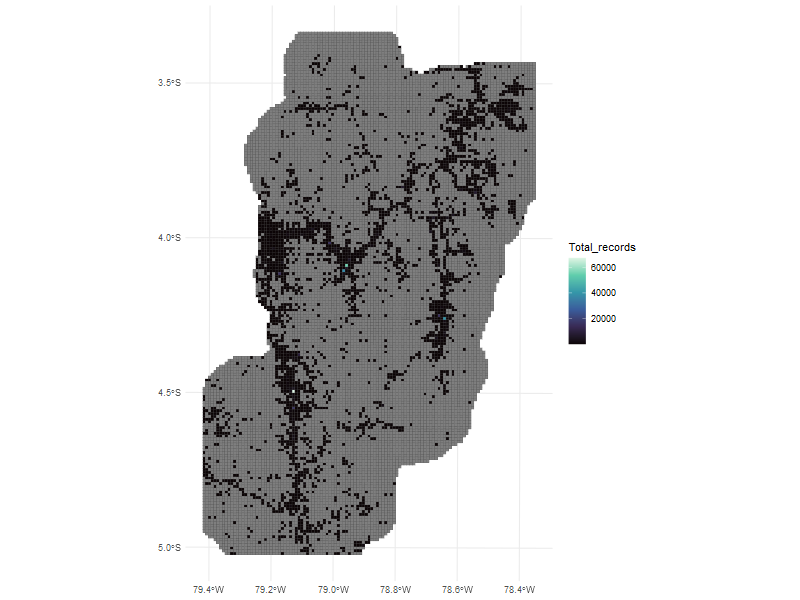

In [21]:
grids_1km_buffer_join = grids_1km_buffer%>% 
  left_join(total_records_species_per_grid, by = "id")

ggplot(grids_1km_buffer_join) +
  geom_sf(aes(fill = Total_records ), color = "grey30", size = 0.1) +
  scale_fill_viridis_c(option = "mako") +
  theme_minimal()

Warning messages:
1: Removed 12813 rows containing non-finite outside the scale range
(`stat_smooth()`). 
2: Removed 12813 rows containing missing values or values outside the scale range
(`geom_point()`). 


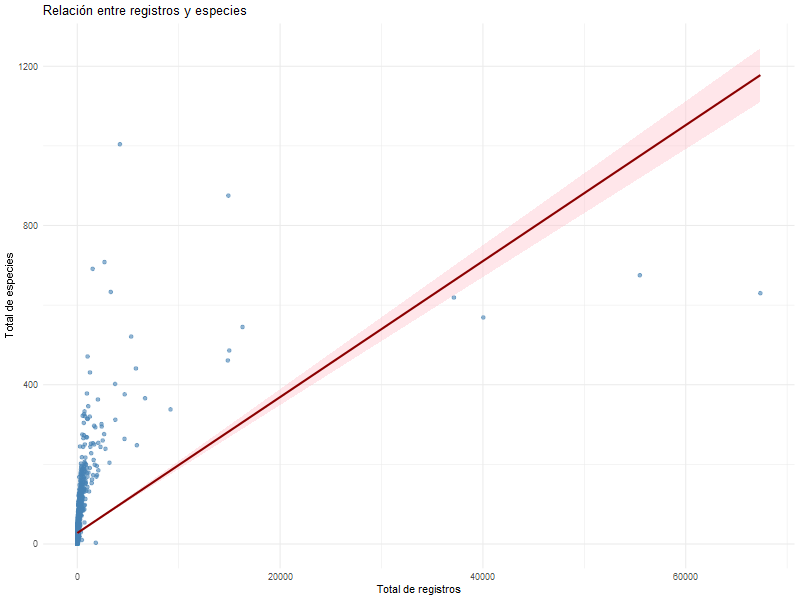

`geom_smooth()` using formula = 'y ~ x'

In [22]:
ggplot(grids_1km_buffer_join, aes(x = Total_records, y =  Total_species   )) +
  geom_point(alpha = 0.6, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "darkred", fill = "pink") +
  theme_minimal() +
  labs(
    x = "Total de registros",
    y = "Total de especies",
    title = "Relación entre registros y especies"
  )

# 6. Sampling coverage

function for calculating coverage using a sliding window

In [23]:


calc_coverage_window_group <- function(group_name,
  grid_sf,
  summary_df,
  records_sf,
  window_size = 25) { # <--- Tú pones el tamaño aquí (ej. 25)

#----------------------------------------------------------
# 1. Preparar grid e índices
#----------------------------------------------------------
grid_base <- grid_sf |>
dplyr::select(id, geometry) |>
dplyr::distinct(id, .keep_all = TRUE)

# Cálculo automático de índices si no existen
if (!all(c("col_idx", "row_idx") %in% names(grid_sf))) {
cent <- sf::st_coordinates(sf::st_centroid(grid_base$geometry))
x_vals <- sort(unique(round(cent[,1], 6)))
y_vals <- sort(unique(round(cent[,2], 6)))
cellsize_x <- min(diff(x_vals))
cellsize_y <- min(diff(y_vals))

grid_base <- grid_base |>
dplyr::mutate(
col_idx = round((cent[,1] - min(x_vals)) / cellsize_x),
row_idx = round((cent[,2] - min(y_vals)) / cellsize_y)
)
} else {
grid_base <- grid_sf |>
dplyr::select(id, col_idx, row_idx, geometry) |>
dplyr::distinct(id, .keep_all = TRUE)
}

#----------------------------------------------------------
# 2. Calcular el Radio (k) basado en el window_size
#----------------------------------------------------------
# Si pides 25, el radio es (25 - 1) / 2 = 12
k <- floor((window_size - 1) / 2)

#----------------------------------------------------------
# 3. Filtrar celdas y registros
#----------------------------------------------------------
focal_ids <- summary_df |>
dplyr::filter(Group == group_name, Total_records > 0) |>
dplyr::distinct(id) |>
dplyr::pull(id)

if (length(focal_ids) == 0) return(NULL)

rec_group <- records_sf |>
sf::st_drop_geometry() |>
dplyr::filter(Group == group_name, !is.na(scientificName)) |>
dplyr::distinct(id, scientificName)

#----------------------------------------------------------
# 4. Funciones auxiliares
#----------------------------------------------------------
make_na_row <- function(focal_id) {
data.frame(id = focal_id, Group = group_name, Sampling_coverage = NA_real_, stringsAsFactors = FALSE)
}

calc_one_cell <- function(focal_id) {
focal_row <- grid_base[grid_base$id == focal_id, ]
if (nrow(focal_row) == 0) return(make_na_row(focal_id))

fc <- focal_row$col_idx[1]
fr <- focal_row$row_idx[1]

# Filtro dinámico usando el radio k calculado
window_ids <- grid_base |>
dplyr::filter(
col_idx >= fc - k, col_idx <= fc + k,
row_idx >= fr - k, row_idx <= fr + k
) |>
dplyr::pull(id)

rec_window <- rec_group |> dplyr::filter(id %in% window_ids)
n_cells_sampled <- length(unique(rec_window$id))

if (n_cells_sampled < 2) return(make_na_row(focal_id))

incid_counts <- rec_window |> group_by(scientificName) |> tally() |> pull(n)
incid_vec <- c(n_cells_sampled, incid_counts)

tryCatch({
res <- iNEXT(incid_vec, q = 0, datatype = "incidence_freq", se = FALSE)
data.frame(
id = focal_id,
Group = group_name,
window_size_used = paste0(window_size, "x", window_size),
n_cells_sampled = n_cells_sampled,
Sampling_coverage = res$DataInfo$SC,
sp_obs = res$DataInfo$S.obs,
stringsAsFactors = FALSE
)
}, error = function(e) make_na_row(focal_id))
}

#----------------------------------------------------------
# 5. Ejecutar y retornar SF
#----------------------------------------------------------
message(paste0("Calculando completitud para ", group_name, " usando ventana de ", window_size, "x", window_size, "..."))
res_df <- purrr::map_dfr(focal_ids, calc_one_cell)

return(grid_base |> dplyr::select(id, geometry) |> dplyr::inner_join(res_df, by = "id"))
}

## 6.1. Plants

In [24]:
# ============================================================
# ANÁLISIS DE SENSIBILIDAD: VENTANA MÓVIL - PLANTS
# ============================================================

# --- Parámetros definidos ---
GROUP_NAME   <- "Plants"
WINDOW_SIZES <- c(3, 5, 7, 9, 11, 13, 15)

# --- Lista para guardar resultados por ventana ---
sensitivity_results_plants <- vector("list", length(WINDOW_SIZES))
names(sensitivity_results_plants) <- paste0(WINDOW_SIZES, "x", WINDOW_SIZES)

for (i in seq_along(WINDOW_SIZES)) {
  
  ws <- WINDOW_SIZES[i]
  
  message(
    "\n[", i, "/", length(WINDOW_SIZES), "] Probando ventana: ",
    ws, "x", ws, " (", ws^2, " km²)"
  )
  
  result <- calc_coverage_window_group(
    group_name  = GROUP_NAME,
    grid_sf     = grids_1km_buffer_join,
    summary_df  = total_record_sp_by_group,
    records_sf  = records_grid_1km_buffer,
    window_size = ws
  )
  
  if (is.null(result)) {
    message("  >> Sin resultados para window_size = ", ws)
    next
  }
  
  # Resumen estadístico para esta ventana
  summary_ws <- result |>
    sf::st_drop_geometry() |>
    dplyr::summarise(
      Group       = GROUP_NAME,
      window_size = ws,
      area_km2    = ws^2,
      n_valid     = sum(!is.na(Sampling_coverage)),
      pct_NA      = round(mean(is.na(Sampling_coverage)) * 100, 1),
      mean_SC     = round(mean(Sampling_coverage, na.rm = TRUE), 3),
      median_SC   = round(median(Sampling_coverage, na.rm = TRUE), 3),
      sd_SC       = round(sd(Sampling_coverage, na.rm = TRUE), 3),
      cv_SC       = round(sd(Sampling_coverage, na.rm = TRUE) / 
                            mean(Sampling_coverage, na.rm = TRUE), 3),
      q25_SC      = round(quantile(Sampling_coverage, 0.25, na.rm = TRUE), 3),
      q75_SC      = round(quantile(Sampling_coverage, 0.75, na.rm = TRUE), 3)
    )
  
  sensitivity_results_plants[[i]] <- list(
    summary = summary_ws,
    sf      = result
  )
  
  message(
    "  >> n_válidas=", summary_ws$n_valid,
    " | %NA=", summary_ws$pct_NA,
    " | SC_mean=", summary_ws$mean_SC,
    " | CV=", summary_ws$cv_SC
  )
}

# --- Tabla resumen consolidada ---
sensitivity_df_plants <- purrr::map_dfr(
  sensitivity_results_plants,
  ~ if (!is.null(.x)) .x$summary
)

print(sensitivity_df_plants)


[1/7] Probando ventana: 3x3 (9 km²)
Calculando completitud para Plants usando ventana de 3x3...
  >> n_válidas=1684 | %NA=19.8 | SC_mean=0.18 | CV=0.821

[2/7] Probando ventana: 5x5 (25 km²)
Calculando completitud para Plants usando ventana de 5x5...
  >> n_válidas=1941 | %NA=7.5 | SC_mean=0.224 | CV=0.756

[3/7] Probando ventana: 7x7 (49 km²)
Calculando completitud para Plants usando ventana de 7x7...
  >> n_válidas=2033 | %NA=3.1 | SC_mean=0.268 | CV=0.7

[4/7] Probando ventana: 9x9 (81 km²)
Calculando completitud para Plants usando ventana de 9x9...
  >> n_válidas=2076 | %NA=1.1 | SC_mean=0.307 | CV=0.654

[5/7] Probando ventana: 11x11 (121 km²)
Calculando completitud para Plants usando ventana de 11x11...
  >> n_válidas=2089 | %NA=0.5 | SC_mean=0.346 | CV=0.601

[6/7] Probando ventana: 13x13 (169 km²)
Calculando completitud para Plants usando ventana de 13x13...
  >> n_válidas=2094 | %NA=0.2 | SC_mean=0.384 | CV=0.549

[7/7] Probando ventana: 15x15 (225 km²)
Calculando completitud

   Group window_size area_km2 n_valid pct_NA mean_SC median_SC sd_SC cv_SC
1 Plants           3        9    1684   19.8   0.180     0.138 0.148 0.821
2 Plants           5       25    1941    7.5   0.224     0.187 0.170 0.756
3 Plants           7       49    2033    3.1   0.268     0.227 0.188 0.700
4 Plants           9       81    2076    1.1   0.307     0.262 0.201 0.654
5 Plants          11      121    2089    0.5   0.346     0.306 0.208 0.601
6 Plants          13      169    2094    0.2   0.384     0.355 0.211 0.549
  q25_SC q75_SC
1  0.062  0.255
2  0.081  0.339
3  0.118  0.403
4  0.145  0.456
5  0.180  0.519
6  0.212  0.571


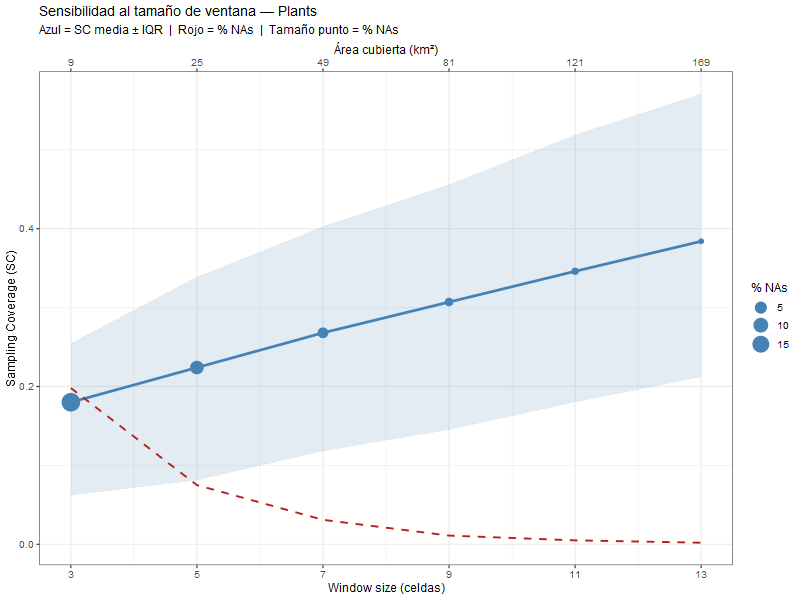

In [25]:


# Cambio marginal entre ventanas consecutivas
sensitivity_df_plants <- sensitivity_df_plants |>
  dplyr::arrange(window_size) |>
  dplyr::mutate(
    delta_SC = abs(mean_SC - dplyr::lag(mean_SC)) / dplyr::lag(mean_SC) * 100
  )

# Gráfico de decisión
sensitivity_plot_plants = ggplot(sensitivity_df_plants, aes(x = window_size)) +
  geom_ribbon(aes(ymin = q25_SC, ymax = q75_SC), alpha = 0.15, fill = "steelblue") +
  geom_line(aes(y = mean_SC), color = "steelblue", linewidth = 1.3) +
  geom_point(aes(y = mean_SC, size = pct_NA), color = "steelblue") +
  geom_line(aes(y = pct_NA / 100), color = "firebrick",
            linetype = "dashed", linewidth = 0.9) +
  scale_size_continuous(name = "% NAs", range = c(2, 8)) +
  scale_x_continuous(breaks = WINDOW_SIZES,
                     sec.axis = sec_axis(~ .^2, name = "Área cubierta (km²)",
                                         breaks = WINDOW_SIZES^2)) +
  labs(
    title    = paste0("Sensibilidad al tamaño de ventana — ", GROUP_NAME),
    subtitle = "Azul = SC media ± IQR  |  Rojo = % NAs  |  Tamaño punto = % NAs",
    x        = "Window size (celdas)",
    y        = "Sampling Coverage (SC)"
  ) +
  theme_bw(base_size = 12)

sensitivity_plot_plants

In [26]:
sc_plants = sensitivity_results_plants$`13x13`$sf #best
sc_plants

Simple feature collection with 2099 features and 6 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 675083.7 ymin: 9444351 xmax: 791083.7 ymax: 9623351
Projected CRS: WGS 84 / UTM zone 17S
First 10 features:
      id  Group window_size_used n_cells_sampled Sampling_coverage sp_obs
1  14261 Plants            13x13              24            0.2619     66
2  14251 Plants            13x13               7            0.0122     28
3  14109 Plants            13x13              22            0.3285    403
4  12483 Plants            13x13              16            0.4334    277
5  12428 Plants            13x13              18            0.3252    386
6  12418 Plants            13x13              28            0.2787    277
7  12419 Plants            13x13              27            0.2997    300
8  12470 Plants            13x13               6            0.0230     18
9  12296 Plants            13x13              18            0.4244    284
10 12331 Plants            13x13

## 6.2. Birds

In [27]:
# ============================================================
# ANÁLISIS DE SENSIBILIDAD: VENTANA MÓVIL - AVES
# ============================================================

# --- Parámetros definidos ---
GROUP_NAME   <- "Aves"
WINDOW_SIZES <- c(3, 5, 7, 9, 11, 13, 15)

# --- Lista para guardar resultados por ventana ---
sensitivity_results_aves <- vector("list", length(WINDOW_SIZES))
names(sensitivity_results_aves) <- paste0(WINDOW_SIZES, "x", WINDOW_SIZES)

for (i in seq_along(WINDOW_SIZES)) {
  
  ws <- WINDOW_SIZES[i]
  
  message(
    "\n[", i, "/", length(WINDOW_SIZES), "] Probando ventana: ",
    ws, "x", ws, " (", ws^2, " km²)"
  )
  
  result <- calc_coverage_window_group(
    group_name  = GROUP_NAME,
    grid_sf     = grids_1km_buffer_join,
    summary_df  = total_record_sp_by_group,
    records_sf  = records_grid_1km_buffer,
    window_size = ws
  )
  
  if (is.null(result)) {
    message("  >> Sin resultados para window_size = ", ws)
    next
  }
  
  # Resumen estadístico para esta ventana
  summary_ws <- result |>
    sf::st_drop_geometry() |>
    dplyr::summarise(
      Group       = GROUP_NAME,
      window_size = ws,
      area_km2    = ws^2,
      n_valid     = sum(!is.na(Sampling_coverage)),
      pct_NA      = round(mean(is.na(Sampling_coverage)) * 100, 1),
      mean_SC     = round(mean(Sampling_coverage, na.rm = TRUE), 3),
      median_SC   = round(median(Sampling_coverage, na.rm = TRUE), 3),
      sd_SC       = round(sd(Sampling_coverage, na.rm = TRUE), 3),
      cv_SC       = round(
        sd(Sampling_coverage, na.rm = TRUE) / 
          mean(Sampling_coverage, na.rm = TRUE), 
        3
      ),
      q25_SC      = round(quantile(Sampling_coverage, 0.25, na.rm = TRUE), 3),
      q75_SC      = round(quantile(Sampling_coverage, 0.75, na.rm = TRUE), 3)
    )
  
  sensitivity_results_aves[[i]] <- list(
    summary = summary_ws,
    sf      = result
  )
  
  message(
    "  >> n_válidas=", summary_ws$n_valid,
    " | %NA=", summary_ws$pct_NA,
    " | SC_mean=", summary_ws$mean_SC,
    " | CV=", summary_ws$cv_SC
  )
}

# --- Tabla resumen consolidada ---
sensitivity_df_aves <- purrr::map_dfr(
  sensitivity_results_aves,
  ~ if (!is.null(.x)) .x$summary
)

print(sensitivity_df_aves)


[1/7] Probando ventana: 3x3 (9 km²)
Calculando completitud para Aves usando ventana de 3x3...
  >> n_válidas=1149 | %NA=14.4 | SC_mean=0.52 | CV=0.504

[2/7] Probando ventana: 5x5 (25 km²)
Calculando completitud para Aves usando ventana de 5x5...
  >> n_válidas=1266 | %NA=5.7 | SC_mean=0.649 | CV=0.379

[3/7] Probando ventana: 7x7 (49 km²)
Calculando completitud para Aves usando ventana de 7x7...
  >> n_válidas=1300 | %NA=3.2 | SC_mean=0.724 | CV=0.319

[4/7] Probando ventana: 9x9 (81 km²)
Calculando completitud para Aves usando ventana de 9x9...
  >> n_válidas=1326 | %NA=1.3 | SC_mean=0.778 | CV=0.268

[5/7] Probando ventana: 11x11 (121 km²)
Calculando completitud para Aves usando ventana de 11x11...
  >> n_válidas=1330 | %NA=1 | SC_mean=0.819 | CV=0.226

[6/7] Probando ventana: 13x13 (169 km²)
Calculando completitud para Aves usando ventana de 13x13...
  >> n_válidas=1335 | %NA=0.6 | SC_mean=0.846 | CV=0.202

[7/7] Probando ventana: 15x15 (225 km²)
Calculando completitud para Aves u

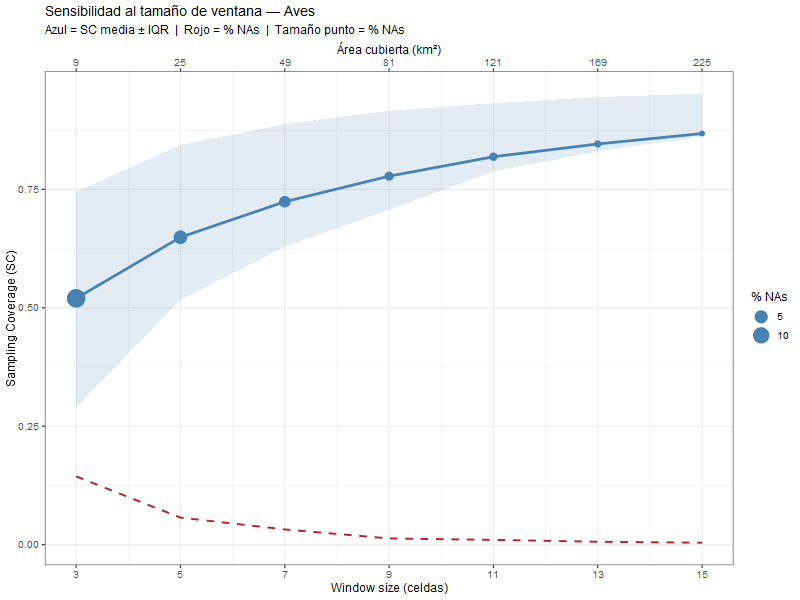

In [28]:


# Cambio marginal entre ventanas consecutivas
sensitivity_df_aves <- sensitivity_df_aves |>
  dplyr::arrange(window_size) |>
  dplyr::mutate(
    delta_SC = abs(mean_SC - dplyr::lag(mean_SC)) / dplyr::lag(mean_SC) * 100
  )

# Gráfico de decisión
sensitivity_plot_aves = ggplot(sensitivity_df_aves, aes(x = window_size)) +
  geom_ribbon(aes(ymin = q25_SC, ymax = q75_SC), alpha = 0.15, fill = "steelblue") +
  geom_line(aes(y = mean_SC), color = "steelblue", linewidth = 1.3) +
  geom_point(aes(y = mean_SC, size = pct_NA), color = "steelblue") +
  geom_line(aes(y = pct_NA / 100), color = "firebrick",
            linetype = "dashed", linewidth = 0.9) +
  scale_size_continuous(name = "% NAs", range = c(2, 8)) +
  scale_x_continuous(breaks = WINDOW_SIZES,
                     sec.axis = sec_axis(~ .^2, name = "Área cubierta (km²)",
                                         breaks = WINDOW_SIZES^2)) +
  labs(
    title    = paste0("Sensibilidad al tamaño de ventana — ", GROUP_NAME),
    subtitle = "Azul = SC media ± IQR  |  Rojo = % NAs  |  Tamaño punto = % NAs",
    x        = "Window size (celdas)",
    y        = "Sampling Coverage (SC)"
  ) +
  theme_bw(base_size = 12)

sensitivity_plot_aves

In [41]:
sc_aves = sensitivity_results_aves$`9x9`$sf

## 6.3. Mammalia

In [31]:
# ============================================================
# ANÁLISIS DE SENSIBILIDAD: VENTANA MÓVIL - MAMMALIA
# ============================================================

# --- Parámetros definidos ---
GROUP_NAME   <- "Mammalia"
WINDOW_SIZES <- c(3, 5, 7, 9, 11, 13, 15)

# --- Lista para guardar resultados por ventana ---
sensitivity_results_mammalia <- vector("list", length(WINDOW_SIZES))
names(sensitivity_results_mammalia) <- paste0(WINDOW_SIZES, "x", WINDOW_SIZES)

for (i in seq_along(WINDOW_SIZES)) {
  
  ws <- WINDOW_SIZES[i]
  
  message(
    "\n[", i, "/", length(WINDOW_SIZES), "] Probando ventana: ",
    ws, "x", ws, " (", ws^2, " km²)"
  )
  
  result <- calc_coverage_window_group(
    group_name  = GROUP_NAME,
    grid_sf     = grids_1km_buffer_join,
    summary_df  = total_record_sp_by_group,
    records_sf  = records_grid_1km_buffer,
    window_size = ws
  )
  
  if (is.null(result)) {
    message("  >> Sin resultados para window_size = ", ws)
    next
  }
  
  # Resumen estadístico para esta ventana
  summary_ws <- result |>
    sf::st_drop_geometry() |>
    dplyr::summarise(
      Group       = GROUP_NAME,
      window_size = ws,
      area_km2    = ws^2,
      n_valid     = sum(!is.na(Sampling_coverage)),
      pct_NA      = round(mean(is.na(Sampling_coverage)) * 100, 1),
      mean_SC     = round(mean(Sampling_coverage, na.rm = TRUE), 3),
      median_SC   = round(median(Sampling_coverage, na.rm = TRUE), 3),
      sd_SC       = round(sd(Sampling_coverage, na.rm = TRUE), 3),
      cv_SC       = round(
        sd(Sampling_coverage, na.rm = TRUE) / 
          mean(Sampling_coverage, na.rm = TRUE),
        3
      ),
      q25_SC      = round(quantile(Sampling_coverage, 0.25, na.rm = TRUE), 3),
      q75_SC      = round(quantile(Sampling_coverage, 0.75, na.rm = TRUE), 3)
    )
  
  sensitivity_results_mammalia[[i]] <- list(
    summary = summary_ws,
    sf      = result
  )
  
  message(
    "  >> n_válidas=", summary_ws$n_valid,
    " | %NA=", summary_ws$pct_NA,
    " | SC_mean=", summary_ws$mean_SC,
    " | CV=", summary_ws$cv_SC
  )
}

# --- Tabla resumen consolidada ---
sensitivity_df_mammalia <- purrr::map_dfr(
  sensitivity_results_mammalia,
  ~ if (!is.null(.x)) .x$summary
)

print(sensitivity_df_mammalia)


[1/7] Probando ventana: 3x3 (9 km²)
Calculando completitud para Mammalia usando ventana de 3x3...
  >> n_válidas=47 | %NA=77.5 | SC_mean=0.372 | CV=0.75

[2/7] Probando ventana: 5x5 (25 km²)
Calculando completitud para Mammalia usando ventana de 5x5...
  >> n_válidas=86 | %NA=58.9 | SC_mean=0.469 | CV=0.563

[3/7] Probando ventana: 7x7 (49 km²)
Calculando completitud para Mammalia usando ventana de 7x7...
  >> n_válidas=121 | %NA=42.1 | SC_mean=0.513 | CV=0.468

[4/7] Probando ventana: 9x9 (81 km²)
Calculando completitud para Mammalia usando ventana de 9x9...
  >> n_válidas=154 | %NA=26.3 | SC_mean=0.534 | CV=0.439

[5/7] Probando ventana: 11x11 (121 km²)
Calculando completitud para Mammalia usando ventana de 11x11...
  >> n_válidas=170 | %NA=18.7 | SC_mean=0.558 | CV=0.368

[6/7] Probando ventana: 13x13 (169 km²)
Calculando completitud para Mammalia usando ventana de 13x13...
  >> n_válidas=177 | %NA=15.3 | SC_mean=0.576 | CV=0.339

[7/7] Probando ventana: 15x15 (225 km²)
Calculando 

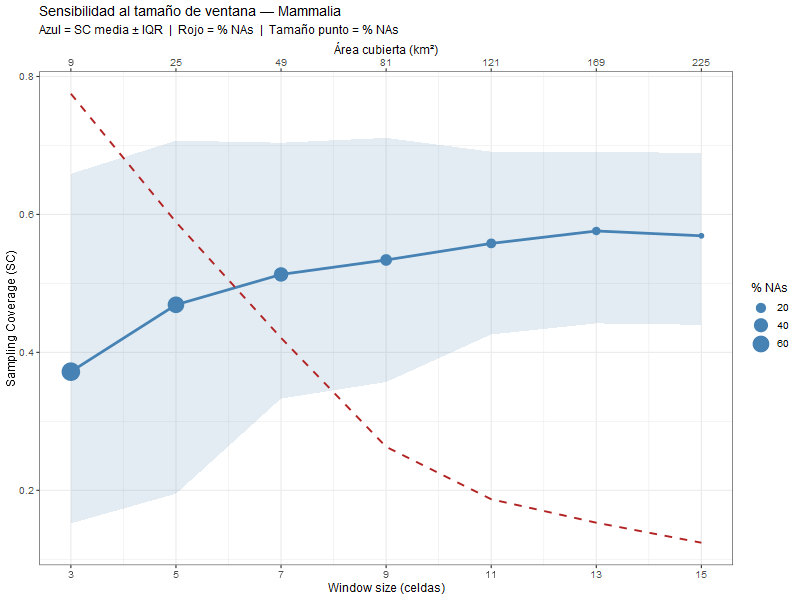

In [32]:

# Cambio marginal entre ventanas consecutivas
sensitivity_df_mammals <- sensitivity_df_mammalia |>
  dplyr::arrange(window_size) |>
  dplyr::mutate(
    delta_SC = abs(mean_SC - dplyr::lag(mean_SC)) / dplyr::lag(mean_SC) * 100
  )

# Gráfico de decisión
sensitivity_plot_mammalia = ggplot(sensitivity_df_mammalia, aes(x = window_size)) +
  geom_ribbon(aes(ymin = q25_SC, ymax = q75_SC), alpha = 0.15, fill = "steelblue") +
  geom_line(aes(y = mean_SC), color = "steelblue", linewidth = 1.3) +
  geom_point(aes(y = mean_SC, size = pct_NA), color = "steelblue") +
  geom_line(aes(y = pct_NA / 100), color = "firebrick",
            linetype = "dashed", linewidth = 0.9) +
  scale_size_continuous(name = "% NAs", range = c(2, 8)) +
  scale_x_continuous(breaks = WINDOW_SIZES,
                     sec.axis = sec_axis(~ .^2, name = "Área cubierta (km²)",
                                         breaks = WINDOW_SIZES^2)) +
  labs(
    title    = paste0("Sensibilidad al tamaño de ventana — ", GROUP_NAME),
    subtitle = "Azul = SC media ± IQR  |  Rojo = % NAs  |  Tamaño punto = % NAs",
    x        = "Window size (celdas)",
    y        = "Sampling Coverage (SC)"
  ) +
  theme_bw(base_size = 12)

sensitivity_plot_mammalia

In [33]:
sc_mammalia = sensitivity_results_mammalia$`9x9`$sf

## 6.4. Amphibia

In [34]:
# ============================================================
# ANÁLISIS DE SENSIBILIDAD: VENTANA MÓVIL - AMPHIBIA
# ============================================================

# --- Parámetros definidos ---
GROUP_NAME   <- "Amphibia"
WINDOW_SIZES <- c(3, 5, 7, 9, 11, 13, 15)

# --- Lista para guardar resultados por ventana ---
sensitivity_results_amphibia <- vector("list", length(WINDOW_SIZES))
names(sensitivity_results_amphibia) <- paste0(WINDOW_SIZES, "x", WINDOW_SIZES)

for (i in seq_along(WINDOW_SIZES)) {
  
  ws <- WINDOW_SIZES[i]
  
  message(
    "\n[", i, "/", length(WINDOW_SIZES), "] Probando ventana: ",
    ws, "x", ws, " (", ws^2, " km²)"
  )
  
  result <- calc_coverage_window_group(
    group_name  = GROUP_NAME,
    grid_sf     = grids_1km_buffer_join,
    summary_df  = total_record_sp_by_group,
    records_sf  = records_grid_1km_buffer,
    window_size = ws
  )
  
  if (is.null(result)) {
    message("  >> Sin resultados para window_size = ", ws)
    next
  }
  
  # Resumen estadístico para esta ventana
  summary_ws <- result |>
    sf::st_drop_geometry() |>
    dplyr::summarise(
      Group       = GROUP_NAME,
      window_size = ws,
      area_km2    = ws^2,
      n_valid     = sum(!is.na(Sampling_coverage)),
      pct_NA      = round(mean(is.na(Sampling_coverage)) * 100, 1),
      mean_SC     = round(mean(Sampling_coverage, na.rm = TRUE), 3),
      median_SC   = round(median(Sampling_coverage, na.rm = TRUE), 3),
      sd_SC       = round(sd(Sampling_coverage, na.rm = TRUE), 3),
      cv_SC       = round(
        sd(Sampling_coverage, na.rm = TRUE) /
          mean(Sampling_coverage, na.rm = TRUE),
        3
      ),
      q25_SC      = round(quantile(Sampling_coverage, 0.25, na.rm = TRUE), 3),
      q75_SC      = round(quantile(Sampling_coverage, 0.75, na.rm = TRUE), 3)
    )
  
  sensitivity_results_amphibia[[i]] <- list(
    summary = summary_ws,
    sf      = result
  )
  
  message(
    "  >> n_válidas=", summary_ws$n_valid,
    " | %NA=", summary_ws$pct_NA,
    " | SC_mean=", summary_ws$mean_SC,
    " | CV=", summary_ws$cv_SC
  )
}

# --- Tabla resumen consolidada ---
sensitivity_df_amphibia <- purrr::map_dfr(
  sensitivity_results_amphibia,
  ~ if (!is.null(.x)) .x$summary
)

print(sensitivity_df_amphibia)



[1/7] Probando ventana: 3x3 (9 km²)
Calculando completitud para Amphibia usando ventana de 3x3...
  >> n_válidas=300 | %NA=39.5 | SC_mean=0.59 | CV=0.381

[2/7] Probando ventana: 5x5 (25 km²)
Calculando completitud para Amphibia usando ventana de 5x5...
  >> n_válidas=385 | %NA=22.4 | SC_mean=0.643 | CV=0.325

[3/7] Probando ventana: 7x7 (49 km²)
Calculando completitud para Amphibia usando ventana de 7x7...
  >> n_válidas=435 | %NA=12.3 | SC_mean=0.677 | CV=0.279

[4/7] Probando ventana: 9x9 (81 km²)
Calculando completitud para Amphibia usando ventana de 9x9...
  >> n_válidas=452 | %NA=8.9 | SC_mean=0.694 | CV=0.267

[5/7] Probando ventana: 11x11 (121 km²)
Calculando completitud para Amphibia usando ventana de 11x11...
  >> n_válidas=459 | %NA=7.5 | SC_mean=0.719 | CV=0.243

[6/7] Probando ventana: 13x13 (169 km²)
Calculando completitud para Amphibia usando ventana de 13x13...
  >> n_válidas=470 | %NA=5.2 | SC_mean=0.739 | CV=0.229

[7/7] Probando ventana: 15x15 (225 km²)
Calculando c

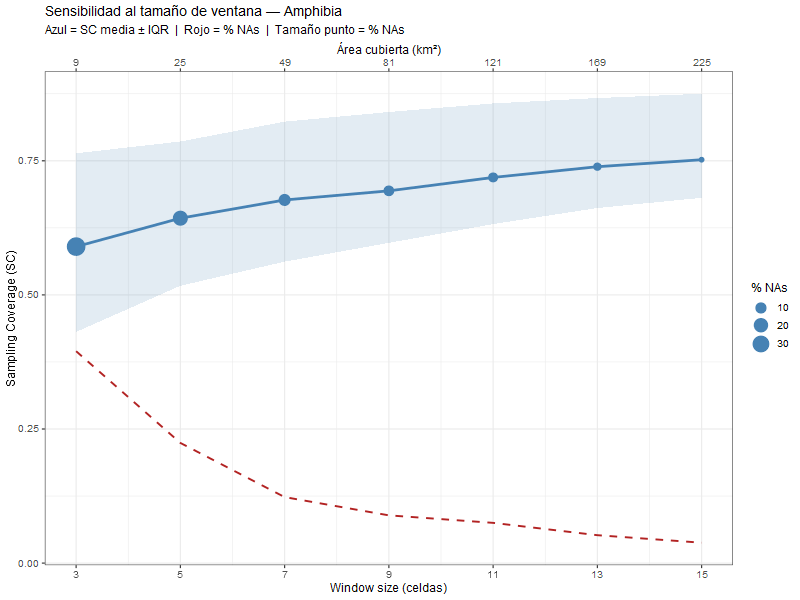

In [35]:

# Cambio marginal entre ventanas consecutivas
sensitivity_df_amphibia <- sensitivity_df_amphibia |>
  dplyr::arrange(window_size) |>
  dplyr::mutate(
    delta_SC = abs(mean_SC - dplyr::lag(mean_SC)) / dplyr::lag(mean_SC) * 100
  )

# Gráfico de decisión
sensitivity_plot_amphibia =ggplot(sensitivity_df_amphibia, aes(x = window_size)) +
  geom_ribbon(aes(ymin = q25_SC, ymax = q75_SC), alpha = 0.15, fill = "steelblue") +
  geom_line(aes(y = mean_SC), color = "steelblue", linewidth = 1.3) +
  geom_point(aes(y = mean_SC, size = pct_NA), color = "steelblue") +
  geom_line(aes(y = pct_NA / 100), color = "firebrick",
            linetype = "dashed", linewidth = 0.9) +
  scale_size_continuous(name = "% NAs", range = c(2, 8)) +
  scale_x_continuous(breaks = WINDOW_SIZES,
                     sec.axis = sec_axis(~ .^2, name = "Área cubierta (km²)",
                                         breaks = WINDOW_SIZES^2)) +
  labs(
    title    = paste0("Sensibilidad al tamaño de ventana — ", GROUP_NAME),
    subtitle = "Azul = SC media ± IQR  |  Rojo = % NAs  |  Tamaño punto = % NAs",
    x        = "Window size (celdas)",
    y        = "Sampling Coverage (SC)"
  ) +
  theme_bw(base_size = 12)

sensitivity_plot_amphibia

In [36]:
sc_amphibia = sensitivity_results_amphibia$`9x9`$sf

## 6.5. Reptilia

In [37]:
# ============================================================
# ANÁLISIS DE SENSIBILIDAD: VENTANA MÓVIL - REPTILIA
# ============================================================

# --- Parámetros definidos ---
GROUP_NAME   <- "Reptilia"
WINDOW_SIZES <- c(3, 5, 7, 9, 11, 13, 15)

# --- Lista para guardar resultados por ventana ---
sensitivity_results_reptilia <- vector("list", length(WINDOW_SIZES))
names(sensitivity_results_reptilia) <- paste0(WINDOW_SIZES, "x", WINDOW_SIZES)

for (i in seq_along(WINDOW_SIZES)) {
  
  ws <- WINDOW_SIZES[i]
  
  message(
    "\n[", i, "/", length(WINDOW_SIZES), "] Probando ventana: ",
    ws, "x", ws, " (", ws^2, " km²)"
  )
  
  result <- calc_coverage_window_group(
    group_name  = GROUP_NAME,
    grid_sf     = grids_1km_buffer_join,
    summary_df  = total_record_sp_by_group,
    records_sf  = records_grid_1km_buffer,
    window_size = ws
  )
  
  if (is.null(result)) {
    message("  >> Sin resultados para window_size = ", ws)
    next
  }
  
  # Resumen estadístico para esta ventana
  summary_ws <- result |>
    sf::st_drop_geometry() |>
    dplyr::summarise(
      Group       = GROUP_NAME,
      window_size = ws,
      area_km2    = ws^2,
      n_valid     = sum(!is.na(Sampling_coverage)),
      pct_NA      = round(mean(is.na(Sampling_coverage)) * 100, 1),
      mean_SC     = round(mean(Sampling_coverage, na.rm = TRUE), 3),
      median_SC   = round(median(Sampling_coverage, na.rm = TRUE), 3),
      sd_SC       = round(sd(Sampling_coverage, na.rm = TRUE), 3),
      cv_SC       = round(
        sd(Sampling_coverage, na.rm = TRUE) /
          mean(Sampling_coverage, na.rm = TRUE),
        3
      ),
      q25_SC      = round(quantile(Sampling_coverage, 0.25, na.rm = TRUE), 3),
      q75_SC      = round(quantile(Sampling_coverage, 0.75, na.rm = TRUE), 3)
    )
  
  sensitivity_results_reptilia[[i]] <- list(
    summary = summary_ws,
    sf      = result
  )
  
  message(
    "  >> n_válidas=", summary_ws$n_valid,
    " | %NA=", summary_ws$pct_NA,
    " | SC_mean=", summary_ws$mean_SC,
    " | CV=", summary_ws$cv_SC
  )
}

# --- Tabla resumen consolidada ---
sensitivity_df_reptilia <- purrr::map_dfr(
  sensitivity_results_reptilia,
  ~ if (!is.null(.x)) .x$summary
)

print(sensitivity_df_reptilia)


[1/7] Probando ventana: 3x3 (9 km²)
Calculando completitud para Reptilia usando ventana de 3x3...
  >> n_válidas=173 | %NA=52.2 | SC_mean=0.501 | CV=0.488

[2/7] Probando ventana: 5x5 (25 km²)
Calculando completitud para Reptilia usando ventana de 5x5...
  >> n_válidas=250 | %NA=30.9 | SC_mean=0.545 | CV=0.412

[3/7] Probando ventana: 7x7 (49 km²)
Calculando completitud para Reptilia usando ventana de 7x7...
  >> n_válidas=302 | %NA=16.6 | SC_mean=0.575 | CV=0.386

[4/7] Probando ventana: 9x9 (81 km²)
Calculando completitud para Reptilia usando ventana de 9x9...
  >> n_válidas=320 | %NA=11.6 | SC_mean=0.605 | CV=0.353

[5/7] Probando ventana: 11x11 (121 km²)
Calculando completitud para Reptilia usando ventana de 11x11...
  >> n_válidas=324 | %NA=10.5 | SC_mean=0.636 | CV=0.31

[6/7] Probando ventana: 13x13 (169 km²)
Calculando completitud para Reptilia usando ventana de 13x13...
  >> n_válidas=333 | %NA=8 | SC_mean=0.654 | CV=0.288

[7/7] Probando ventana: 15x15 (225 km²)
Calculando c

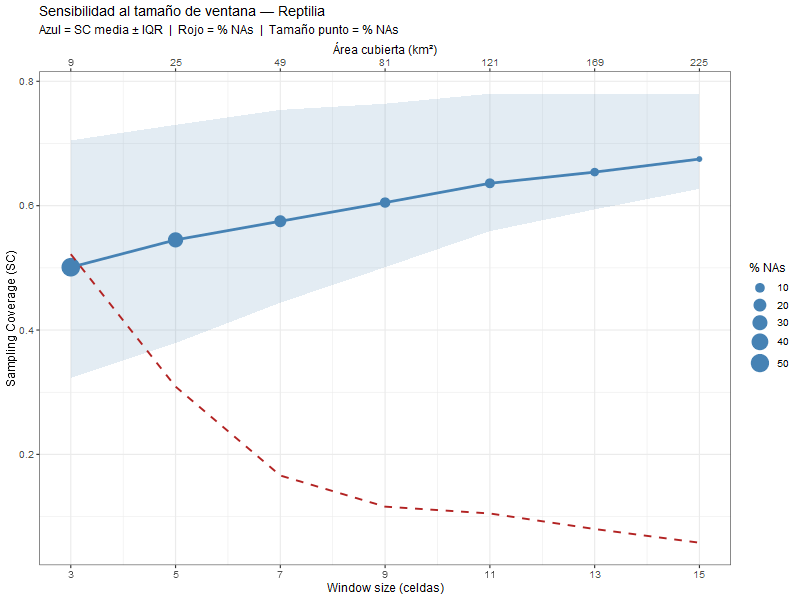

In [38]:

# Cambio marginal entre ventanas consecutivas
sensitivity_df_reptilia <- sensitivity_df_reptilia |>
  dplyr::arrange(window_size) |>
  dplyr::mutate(
    delta_SC = abs(mean_SC - dplyr::lag(mean_SC)) / dplyr::lag(mean_SC) * 100
  )

# Gráfico de decisión
sensitivity_plot_reptilia = ggplot(sensitivity_df_reptilia, aes(x = window_size)) +
  geom_ribbon(aes(ymin = q25_SC, ymax = q75_SC), alpha = 0.15, fill = "steelblue") +
  geom_line(aes(y = mean_SC), color = "steelblue", linewidth = 1.3) +
  geom_point(aes(y = mean_SC, size = pct_NA), color = "steelblue") +
  geom_line(aes(y = pct_NA / 100), color = "firebrick",
            linetype = "dashed", linewidth = 0.9) +
  scale_size_continuous(name = "% NAs", range = c(2, 8)) +
  scale_x_continuous(breaks = WINDOW_SIZES,
                     sec.axis = sec_axis(~ .^2, name = "Área cubierta (km²)",
                                         breaks = WINDOW_SIZES^2)) +
  labs(
    title    = paste0("Sensibilidad al tamaño de ventana — ", GROUP_NAME),
    subtitle = "Azul = SC media ± IQR  |  Rojo = % NAs  |  Tamaño punto = % NAs",
    x        = "Window size (celdas)",
    y        = "Sampling Coverage (SC)"
  ) +
  theme_bw(base_size = 12)

sensitivity_plot_reptilia

In [39]:
sc_reptilia = sensitivity_results_reptilia$`11x11`$sf

# 7. Exportar resultados

In [42]:
st_write(sc_plants, "../../../DATOS/SHP/Biodiversidad/sampl_cov_plants.shp", append=FALSE)
st_write(sc_aves, "../../../DATOS/SHP/Biodiversidad/sampl_cov_aves.shp", append=FALSE)
st_write(sc_mammalia, "../../../DATOS/SHP/Biodiversidad/sampl_cov_mammals.shp", append=FALSE)
st_write(sc_amphibia, "../../../DATOS/SHP/Biodiversidad/sampl_cov_amphibia.shp", append=FALSE)
st_write(sc_reptilia, "../../../DATOS/SHP/Biodiversidad/sampl_cov_reptilia.shp", append=FALSE)
st_write(grids_1km_buffer_join, "../../../DATOS/SHP/Biodiversidad/grids_records_sp.shp", append=FALSE)
write.csv(total_record_sp_by_group, "../../../DATOS/Datasets/Biodiversidad/grids_records_sp_by_group.csv")

 #st_write(results_sampling_effor_filter, "Results/shp/grid_10km_sampling_filter.shp", append=FALSE)

Deleting layer `sampl_cov_plants' using driver `ESRI Shapefile'
Writing layer `sampl_cov_plants' to data source 
  `../../../DATOS/SHP/Biodiversidad/sampl_cov_plants.shp' using driver `ESRI Shapefile'
Writing 2099 features with 6 fields and geometry type Polygon.


Warning message:
In abbreviate_shapefile_names(obj) :
  Field names abbreviated for ESRI Shapefile driver


Deleting layer `sampl_cov_aves' using driver `ESRI Shapefile'
Writing layer `sampl_cov_aves' to data source 
  `../../../DATOS/SHP/Biodiversidad/sampl_cov_aves.shp' using driver `ESRI Shapefile'
Writing 1343 features with 6 fields and geometry type Polygon.


Warning message:
In abbreviate_shapefile_names(obj) :
  Field names abbreviated for ESRI Shapefile driver


Deleting layer `sampl_cov_mammals' using driver `ESRI Shapefile'
Writing layer `sampl_cov_mammals' to data source 
  `../../../DATOS/SHP/Biodiversidad/sampl_cov_mammals.shp' using driver `ESRI Shapefile'
Writing 209 features with 6 fields and geometry type Polygon.


...

Warning message:
In abbreviate_shapefile_names(obj) :
  Field names abbreviated for ESRI Shapefile driver


Deleting layer `sampl_cov_reptilia' using driver `ESRI Shapefile'
Writing layer `sampl_cov_reptilia' to data source 
  `../../../DATOS/SHP/Biodiversidad/sampl_cov_reptilia.shp' using driver `ESRI Shapefile'
Writing 362 features with 6 fields and geometry type Polygon.


Warning message:
In abbreviate_shapefile_names(obj) :
  Field names abbreviated for ESRI Shapefile driver


Deleting layer `grids_records_sp' using driver `ESRI Shapefile'
Writing layer `grids_records_sp' to data source 
  `../../../DATOS/SHP/Biodiversidad/grids_records_sp.shp' using driver `ESRI Shapefile'
Writing 15779 features with 7 fields and geometry type Polygon.


Warning message:
In abbreviate_shapefile_names(obj) :
  Field names abbreviated for ESRI Shapefile driver
